# Parameters

In [1]:
from common.utils import (
    omega_c,
    delta0_from_N_Gamma,
    Omega0_from_N_Gamma,
    default_three_phase_protocol,
)

from pathlib import Path

%reload_ext autoreload
%autoreload 2

output_dir = Path("output")

# Homogeneous vs Inhomogeneous

In [8]:
from quantum_trajectories.run_sim import (
    run_h_sim,
    run_inh_sim,
)

# common fixed
Gamma = 1; dt = 1e-2; num_snapshots=100
# param
N = 12
dN = 0
N1 = 6
omega1 = 0.6
ntraj = 1000
# Model and parameters
Omega_ratio = 0.4
Omega0 = Omega_ratio * omega_c(N//2, Gamma)
delta0 = 1
# protocol phases
phases = default_three_phase_protocol(
    T1=10000.0,
    T2=100000.0,
    T3=1000.0,
    delta0=delta0,
    Omega0=Omega0,
)

homogeneous_ensemble = run_h_sim(
    N=N,
    dN=dN,
    dt=dt,
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
    ntraj=ntraj,
    num_snapshots=num_snapshots,
    seed=1234,
    n_processes=-1,
    )

inhomogeneous_ensemble = run_inh_sim(
    N=N,
    dN=dN,
    N1=N1,
    omega_1=omega1,
    dt=dt,
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
    ntraj=ntraj,
    num_snapshots=num_snapshots,
    seed=1234,
    n_processes=-1,
    )


from parser.moments import MomentSeries
from quantum_trajectories.j_moments import compute_ensemble_j_moments
from quantum_trajectories.mfe_residuals import compute_mfe_residuals

# Initialize moments
h_moments = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=homogeneous_ensemble.parameters,
)
inh_moments = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=inhomogeneous_ensemble.parameters,
)

# j moments
h_moments.J = compute_ensemble_j_moments(
    homogeneous_ensemble,
    n_processes=-1,
)
inh_moments.J = compute_ensemble_j_moments(
    inhomogeneous_ensemble,
    n_processes=-1,
)

# MFE residuals
inh_moments.mfe_residuals = compute_mfe_residuals(
    inh_moments.J,
    parameters=inh_moments.parameters,
)

Precompute: 0.01 seconds.
Pool startup: 10 processes in 0.10 seconds.


simulate trajectories: 100%|██████████| 1000/1000 [10:57:04<00:00, 39.42s/it]   

Simulation step summary (avg per trajectory): total steps=11220098.83, steps without precompute=120109.71
homogeneous simulation runtime: 8930.765130583022
Precompute: 0.00 seconds.


Pool startup: 10 processes in 0.09 seconds.


simulate trajectories: 100%|██████████| 1000/1000 [3:18:16<00:00, 11.90s/it]   

Simulation step summary (avg per trajectory): total steps=11218757.84, steps without precompute=118739.20
inhomogeneous simulation runtime: 8766.166978291993



compute_ensemble_j_moments: 100%|██████████| 1000/1000 [00:12<00:00, 76.98it/s]


Residual L1 norm
Phase 1 - end: 2.895e-02, min: 0.000e+00
Phase 2 - end: 1.834e-02, min: 1.013e-02
Phase 3 - end: 2.296e-05, min: 2.296e-05


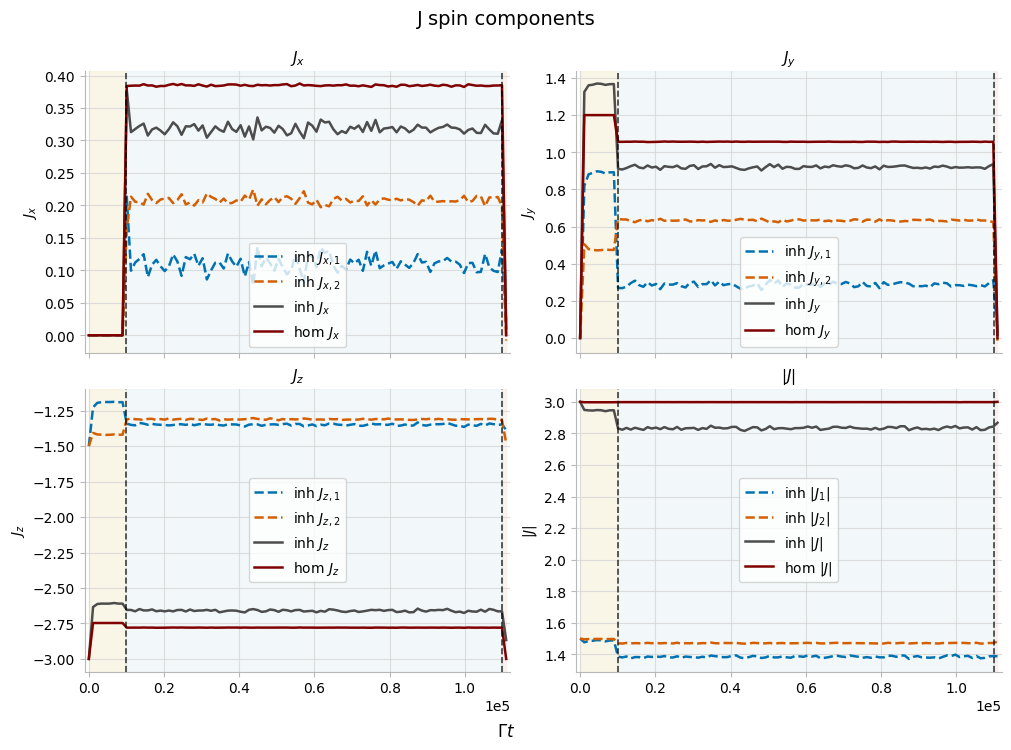

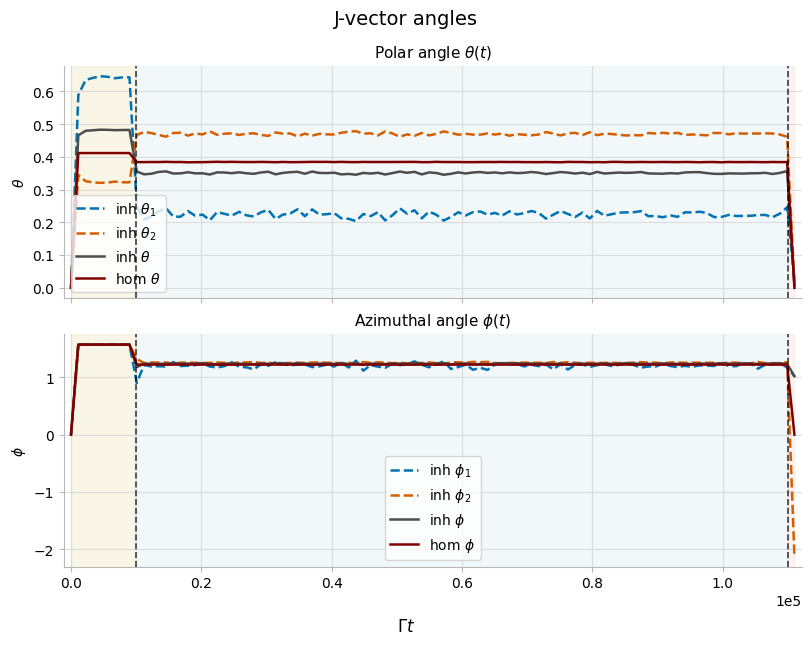

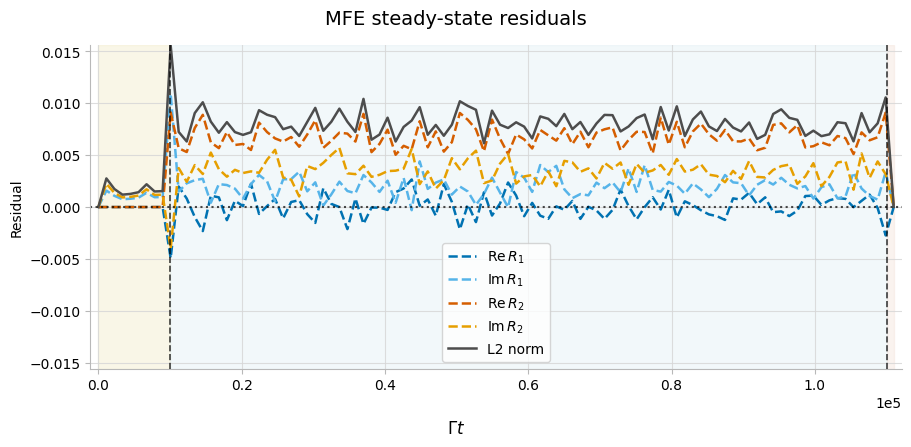

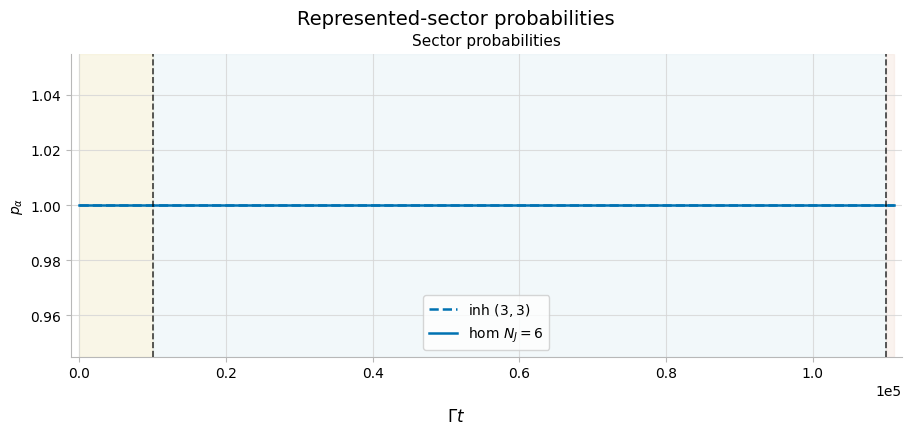

In [9]:
from common.plotting import (
    plot_spin_components,
    plot_j_angles,
)
from quantum_trajectories.plotting_mfe_residuals import plot_mfe_residuals
from quantum_trajectories.plotting_diagnostics import plot_sector_probabilities

fig, axes = plot_spin_components(
    inh_moments.J,
    phases=phases,
    label="inh",
    # output_path = output_dir / "J_spin_components.png",
    )
fig, axes = plot_spin_components(
    h_moments.J,
    phases=phases,
    label="hom",
    axes=axes,
    colour_index=1,
    output_path = output_dir / "J_spin_components.png",
    )

fig, axes = plot_j_angles(
    inh_moments.J,
    phases=phases,
    label = "inh",
    # output_path = output_dir / "J_spin_angles.png",
)
fig, axes = plot_j_angles(
    h_moments.J,
    phases=phases,
    label="hom",
    axes=axes,
    colour_index=1,
    output_path = output_dir / "J_spin_angles.png",
)

fig, axes = plot_mfe_residuals(
    inh_moments.mfe_residuals,
    phases=phases,
    output_path = output_dir / "mfe_residuals.png",
)


fig, axes = plot_sector_probabilities(
    inhomogeneous_ensemble,
    phases=phases,
    label="inh",
    style_index=1
)
fig, axes = plot_sector_probabilities(
    homogeneous_ensemble,
    phases=phases,
    label="hom",
    axes=axes,
    output_path = output_dir / "sector_probabilities.png",
)


# Inhomogeneous vs Homogeneous

In [ ]:
from quantum_trajectories.run_sim import (
    run_h_sim,
    run_inh_sim,
)

# common fixed
Gamma = 1; dt = 1e-2; num_snapshots=200
# param
N = 20 
dN = 0
N1 = 10
omega1 = 0.7
ntraj = 100
# Model and parameters
Omega_ratio = 0.4
Omega0 = Omega_ratio * omega_c(N//2, Gamma)
delta0 = 1
# protocol phases
phases = default_three_phase_protocol(
    T1=50000.0,
    T2=100000.0,
    T3=1000.0,
    delta0=delta0,
    Omega0=Omega0,
)

homogeneous_ensemble = run_h_sim(
    N=N,
    dN=dN,
    dt=dt,
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
    ntraj=ntraj,
    num_snapshots=num_snapshots,
    seed=1234,
    n_processes=-1,
    )

inhomogeneous_ensemble = run_inh_sim(
    N=N,
    dN=dN,
    N1=N1,
    omega_1=omega1,
    dt=dt,
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
    ntraj=ntraj,
    num_snapshots=num_snapshots,
    seed=1234,
    n_processes=-1,
    )


from parser.moments import MomentSeries
from quantum_trajectories.j_moments import compute_ensemble_j_moments
from quantum_trajectories.mfe_residuals import compute_mfe_residuals

# Initialize moments
h_moments = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=homogeneous_ensemble.parameters,
)
inh_moments = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=inhomogeneous_ensemble.parameters,
)

# j moments
h_moments.J = compute_ensemble_j_moments(
    homogeneous_ensemble,
    n_processes=-1,
)
inh_moments.J = compute_ensemble_j_moments(
    inhomogeneous_ensemble,
    n_processes=-1,
)

# MFE residuals
inh_moments.mfe_residuals = compute_mfe_residuals(
    inh_moments.J,
    parameters=inh_moments.parameters,
)

Precompute: 0.00 seconds.
Pool startup: 10 processes in 0.17 seconds.


simulate trajectories:   0%|          | 0/100 [00:00<?, ?it/s]Process SpawnPoolWorker-41:
Process SpawnPoolWorker-43:
Process SpawnPoolWorker-49:
Process SpawnPoolWorker-50:
Process SpawnPoolWorker-45:
Process SpawnPoolWorker-48:
Process SpawnPoolWorker-46:
Process SpawnPoolWorker-44:
Process SpawnPoolWorker-47:
simulate trajectories:   0%|          | 0/100 [00:51<?, ?it/s]Process SpawnPoolWorker-42:

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/ashar/.pyenv/versions/3.12.3/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/ashar/.pyenv/versions/3.12.3/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/ashar/.pyenv/versions/3.12.3/lib/python3.12/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^

KeyboardInterrupt: 

Residual L1 norm
Phase 1: 4.281e-06
Phase 2: 2.201e-10
Phase 3: 2.201e-10


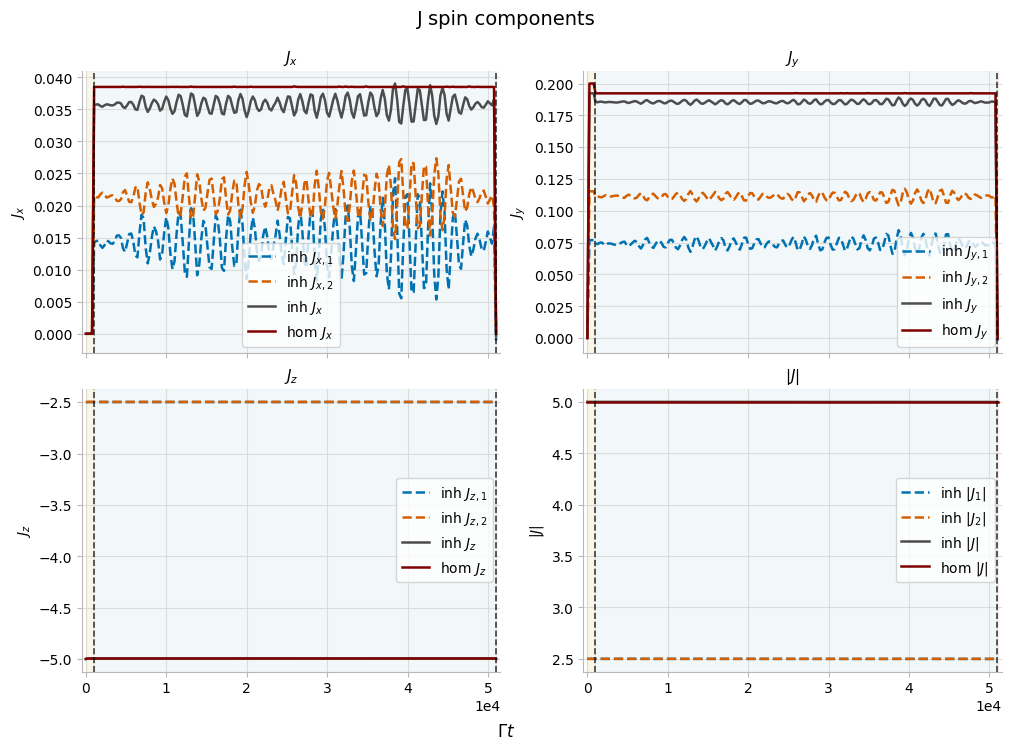

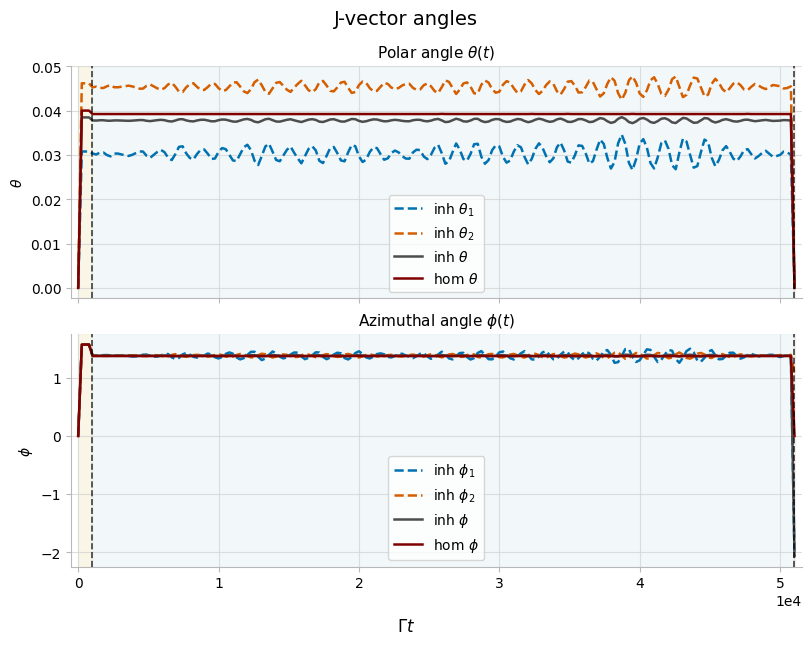

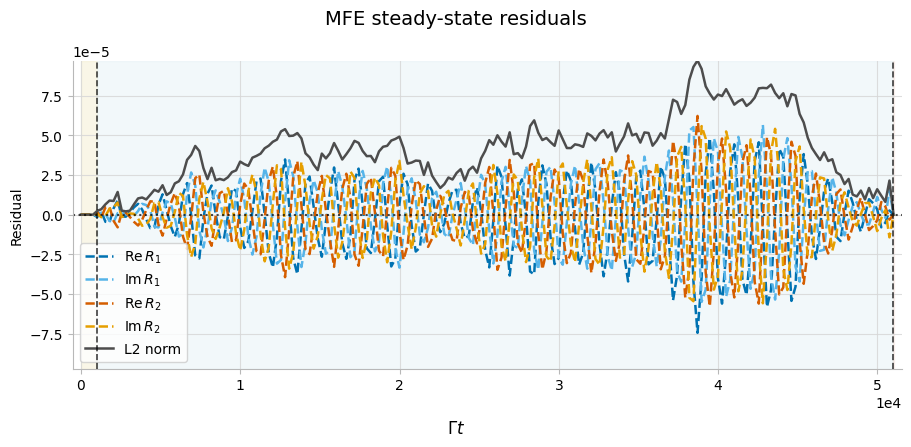

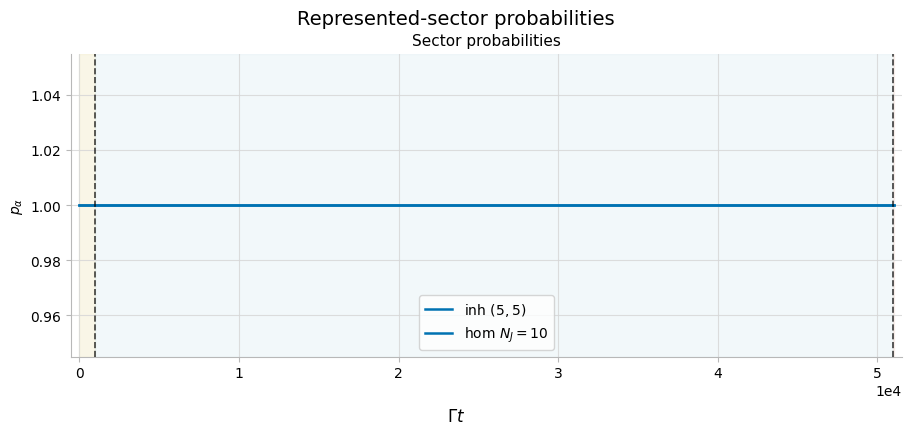

In [ ]:
from common.plotting import (
    plot_spin_components,
    plot_j_angles,
    plot_mfe_residuals,
)
from quantum_trajectories.plotting_diagnostics import plot_sector_probabilities

fig, axes = plot_spin_components(
    inh_moments.J,
    phases=phases,
    label="inh",
    # output_path = output_dir / "J_spin_components.png",
    )
fig, axes = plot_spin_components(
    h_moments.J,
    phases=phases,
    label="hom",
    axes=axes,
    colour_index=1,
    output_path = output_dir / "J_spin_components.png",
    )

fig, axes = plot_j_angles(
    inh_moments.J,
    phases=phases,
    label = "inh",
    # output_path = output_dir / "J_spin_angles.png",
)
fig, axes = plot_j_angles(
    h_moments.J,
    phases=phases,
    label="hom",
    axes=axes,
    colour_index=1,
    output_path = output_dir / "J_spin_angles.png",
)

fig, axes = plot_mfe_residuals(
    inh_moments.mfe_residuals,
    phases=phases,
    output_path = output_dir / "mfe_residuals.png",
)


fig, axes = plot_sector_probabilities(
    inhomogeneous_ensemble,
    phases=phases,
    label="inh",
)
fig, axes = plot_sector_probabilities(
    homogeneous_ensemble,
    phases=phases,
    label="hom",
    axes=axes,
    # output_path = output_dir / "sector_probabilities_1.png",
)


In [ ]:
import sys
import time
from common.utils import Omega_Gamma_from_cavity_parameters
from quantum_trajectories.state_helpers import (
    centered_sector_initial_coeffs,
    centered_group_resolved_sector_initial_coeffs,
)
from quantum_trajectories.ensamble_sim import run_trajectory_ensemble

def run_sim_hom(
    N=20,
    dN=0,
    N1=10,
    dt=1e-2,
    Gamma=1.0,
    ntraj=100,
    shifted_jump_operator=True,
    omega_1=0.7,
    n_processes=10,
):

    N_J = N // 2

    # Model and parameters
    Omega_ratio = 0.4
    Omega0 = Omega_ratio * omega_c(N_J, Gamma)
    delta0 = 1

    # protocol phases
    phases = default_three_phase_protocol(
        T1=10.0,
        T2=10.0,
        T3=10.0,
        delta0=delta0,
        Omega0=Omega0,
    )

    # sector coeff.
    homogeneous_sector_coeffs = centered_sector_initial_coeffs(
            N,
            dN=dN,
            sector_distribution="binomial",
        )
    homogeneous_ratio_check = check_initial_sector_omega_ratio(
            homogeneous_sector_coeffs,
            Omega=max(abs(phase.omega) for phase in phases),
            Gamma=Gamma,
        )
    if not homogeneous_ratio_check["is_valid"]:
        sys.exit(
            "Omega/Omega_c check not valid for homogeneous run: "
            f"Omega={homogeneous_ratio_check['omega']}, Omega_c={homogeneous_ratio_check['omega_c']}, "
            f"smallest Nj={homogeneous_ratio_check['min_nj']}, ratio={homogeneous_ratio_check['ratio']}"
        )
        return

    # simulation
    t0 = time.perf_counter()
    homogeneous_ensemble = run_trajectory_ensemble(
            N=N,
            Gamma=Gamma,
            phases=phases,
            sector_coeffs=homogeneous_sector_coeffs,
            dt=dt,
            num_snapshots=num_snapshots,
            seed=seed,
            ntraj=ntraj,
            shifted_jump_operator=shifted_jump_operator,
            n_processes=n_processes,
            chunksize=1,
            verbose=True,
        )
    simulation_time = time.perf_counter() - t0
    print("homogeneous simulation runtime:", simulation_time)

    return homogeneous_ensemble, phases

homogeneous_ensemble1, phases = run_sim_hom(
    N=20,
    dN=2,
    N1=10,
    dt=1e-2,
    Gamma=1.0,
    ntraj=1000,
    shifted_jump_operator=True,
    omega_1=0.7,
    n_processes=10,
    )

homogeneous_ensemble2, phases = run_sim_hom(
    N=20,
    dN=2,
    N1=10,
    dt=1e-2,
    Gamma=1.0,
    ntraj=1,
    shifted_jump_operator=True,
    omega_1=0.7,
    n_processes=10,
    )

Precompute: 0.02 seconds.
Pool startup: 10 processes in 0.22 seconds.


simulate trajectories: 100%|██████████| 1000/1000 [01:37<00:00, 10.23it/s]


Simulation step summary (avg per trajectory): total steps=3205.70, steps without precompute=220.70
homogeneous simulation runtime: 98.0842155420105
Precompute: 0.04 seconds.
Pool startup: 10 processes in 0.21 seconds.


simulate trajectories: 100%|██████████| 1/1 [00:02<00:00,  2.47s/it]

Simulation step summary (avg per trajectory): total steps=3214.00, steps without precompute=229.00
homogeneous simulation runtime: 2.8253649169928394


compute_ensemble_j_moments: 100%|██████████| 1000/1000 [00:14<00:00, 69.64it/s]


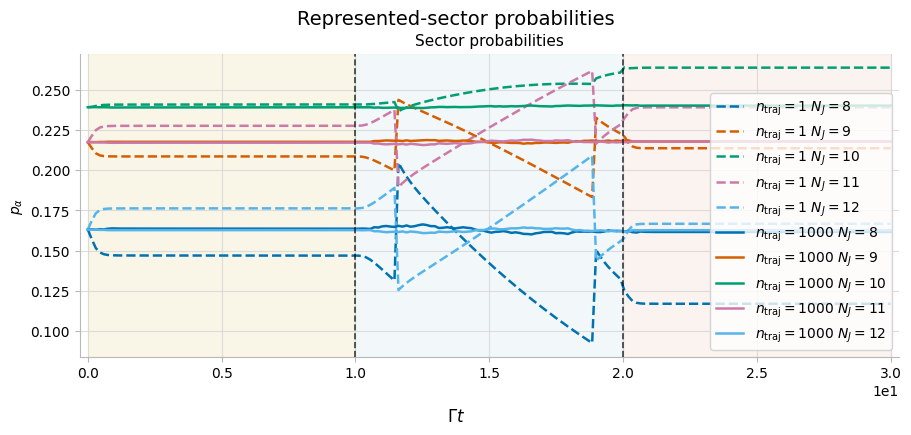

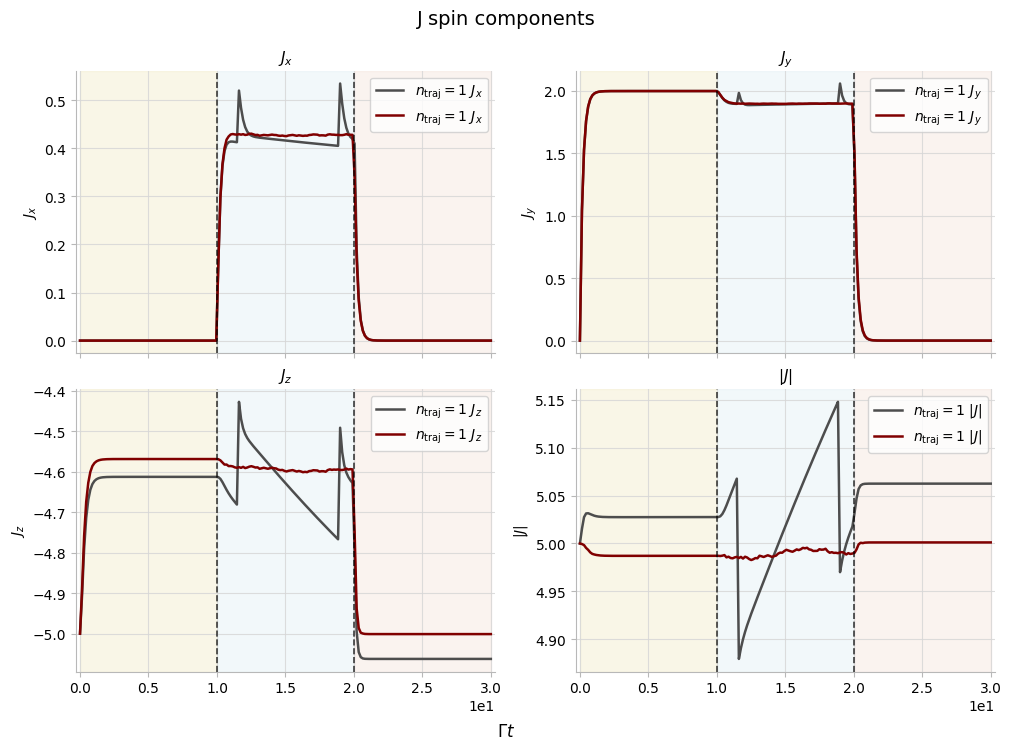

In [ ]:
from quantum_trajectories.plotting_diagnostics import plot_sector_probabilities

fig, axes = plot_sector_probabilities(
    homogeneous_ensemble2,
    phases=phases,
    label=r"$n_{\mathrm{traj}} = 1$",
    style_index=1
    # axes=axes,
    # output_path = output_dir / "sector_probabilities_1.png",
)

fig, axes = plot_sector_probabilities(
    homogeneous_ensemble1,
    phases=phases,
    label=r"$n_{\mathrm{traj}} = 1000$",
    axes=axes,
    style_index=0,
    # output_path = output_dir / "sector_probabilities_compare.png",
)



# Initialize moments
h_moments2 = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=homogeneous_ensemble2.parameters,
)
h_moments1 = MomentSeries(
    phases=phases,
    num_snapshots=num_snapshots,
    parameters=homogeneous_ensemble1.parameters,
)

# j moments
h_moments2.J = compute_ensemble_j_moments(
    homogeneous_ensemble2,
    n_processes=-1,
)
h_moments1.J = compute_ensemble_j_moments(
    homogeneous_ensemble1,
    n_processes=-1,
)


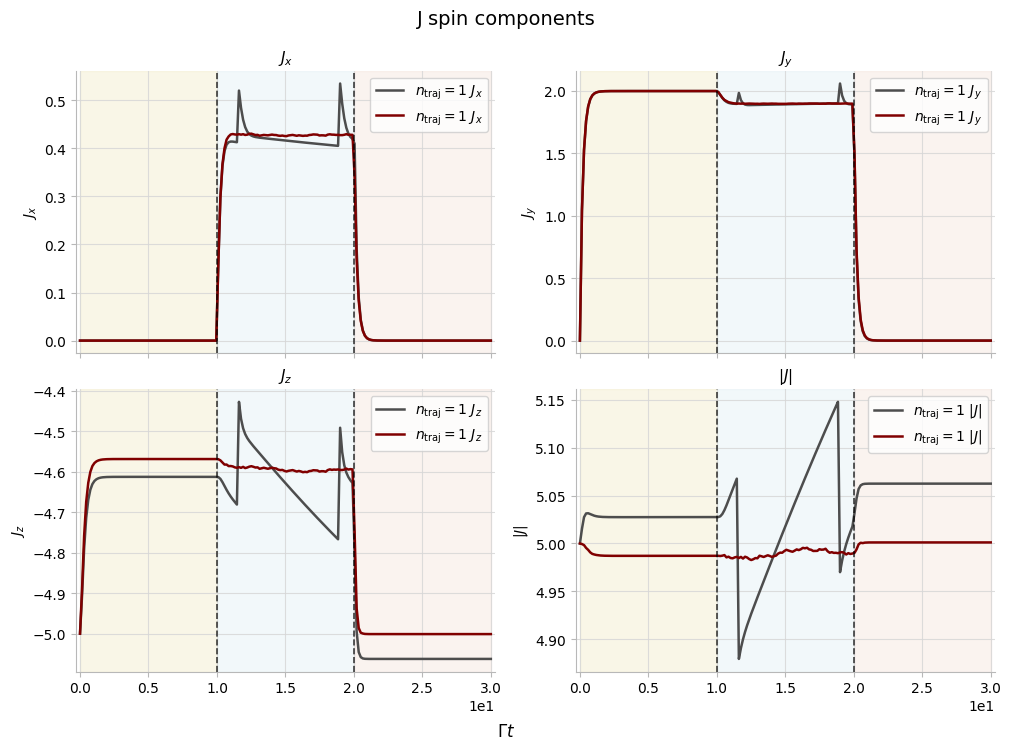

In [ ]:
fig, axes = plot_spin_components(
    h_moments2.J,
    phases=phases,
    label=r"$n_{\mathrm{traj}} = 1$",
    # output_path = output_dir / "J_spin_components.png",
    )
fig, axes = plot_spin_components(
    h_moments1.J,
    phases=phases,
    label=r"$n_{\mathrm{traj}} = 1$",
    axes=axes,
    colour_index=1,
    # output_path = output_dir / "J_spin_components.png",
    )
